# QMM Guided JSON Runner

This notebook asks what you need from the run and what you want to simulate.

It then:
1. builds a valid QMM JSON config
2. saves it into `QMM/examples/generated/`
3. runs `qmm`
4. shows the generated outputs
5. displays generated PNG plots inline when plotting is enabled

The guided flow uses plain `input()` prompts, so it works without `ipywidgets`.


In [11]:
from pathlib import Path
import json
import sys
from IPython.display import Image, Markdown, display

candidate_roots = []
seen = set()
for base in [Path.cwd(), *Path.cwd().parents]:
    for candidate in (base, base / 'QMM'):
        resolved = candidate.resolve()
        marker = str(resolved)
        if marker not in seen:
            seen.add(marker)
            candidate_roots.append(resolved)
ROOT = None
for candidate in candidate_roots:
    if (candidate / 'src' / 'qmm').exists() and (candidate / 'examples').exists():
        ROOT = candidate.resolve()
        break
if ROOT is None:
    raise RuntimeError('Could not find the QMM project root from this notebook.')

SRC_DIR = ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from qmm.qmm_json_helper import (
    PRESET_DESCRIPTIONS,
    available_model_families,
    available_models,
    build_configs,
    choose_python,
    default_request,
    locate_qmm_root,
    parse_float_list,
    parse_yes_no,
    preset_names,
    python_details,
    run_configs,
    save_configs,
    summarize_run,
)

PYTHON_BIN = choose_python(ROOT)
PYTHON_INFO = python_details(ROOT, PYTHON_BIN)
MODELS = available_models(ROOT, PYTHON_BIN)
MODEL_FAMILIES = available_model_families(ROOT, PYTHON_BIN)

print(f'QMM root: {ROOT}')
print(f'Runner Python: {PYTHON_BIN}')
print(f'Runner version: {PYTHON_INFO["version"]}')
print(f'Matplotlib available for plots: {PYTHON_INFO["has_matplotlib"]}')
print('Available mean fields and excluded-volume rules:')
for mean_field, family in MODEL_FAMILIES.items():
    excluded_text = ', '.join(family['excluded_volumes'])
    parameter_text = family['parameter_name'] or 'none'
    print(f"- {mean_field}: excluded_volume={excluded_text}, parameter={parameter_text}")


QMM root: /Users/dajuarez4/Documents/QuarkMatt/good_repo/QMM
Runner Python: /opt/anaconda3/envs/tovsolver/bin/python
Runner version: [3, 11, 15]
Matplotlib available for plots: True
Available mean fields and excluded-volume rules:
- clausius: excluded_volume=vdw, cs, tvm, parameter=c
- dieterici: excluded_volume=vdw, parameter=alpha
- pr: excluded_volume=vdw, parameter=none
- rks: excluded_volume=vdw, parameter=none
- vdw: excluded_volume=vdw, cs, tvm, parameter=none


In [12]:
print('Available presets:')
for name in preset_names():
    print(f'- {name}: {PRESET_DESCRIPTIONS[name]}')

print('\nAvailable models:')
for name, info in sorted(MODELS.items()):
    parameter = info['parameter_name'] or 'none'
    capabilities = []
    if info['supports_quantum']:
        capabilities.append('quantum')
    if info['supports_symmetric_quarkyonic']:
        capabilities.append('sym-quarkyonic')
    if info['supports_asymmetric_hadronic']:
        capabilities.append('asym-fit')
    if info['supports_asymmetric_quarkyonic']:
        capabilities.append('asym-quarkyonic')
    print(f'- {name}: parameter={parameter}, capabilities={", ".join(capabilities)}')


Available presets:
- ground_state_only: Fit symmetric nuclear matter at saturation only.
- critical_point: Ground state plus the finite-temperature critical point.
- symmetric_quarkyonic: Ground state plus symmetric quarkyonic matter.
- full_symmetric: Ground state, critical point, hadronic EOS, and symmetric quarkyonic matter.
- asymmetric_fixed_y: Asymmetric fixed-y quarkyonic matter without beta equilibrium.
- asymmetric_beta: Asymmetric quarkyonic matter in beta equilibrium.
- asymmetric_beta_critical_point: Asymmetric beta-equilibrium matter plus the finite-temperature critical point.
- asymmetric_beta_neutron_star: Asymmetric beta-equilibrium matter plus a neutron-star sequence.
- baryquark_symmetric: Symmetric baryquark matter demo.
- custom: Choose each workflow block manually.

Available models:
- clausius: parameter=c, capabilities=quantum, sym-quarkyonic, asym-fit, asym-quarkyonic
- clausius_cs: parameter=c, capabilities=quantum, sym-quarkyonic, asym-fit, asym-quarkyonic
- c

In [13]:
def choose_option(title, options, default_key=None, descriptions=None):
    keys = list(options)
    print(title)
    for index, key in enumerate(keys, 1):
        label = key
        if descriptions and key in descriptions:
            label = f'{key} - {descriptions[key]}'
        print(f'  {index}. {label}')
    prompt = 'Select option'
    if default_key is not None:
        prompt += f' [{default_key}]'
    prompt += ': '
    raw = input(prompt).strip()
    if not raw:
        if default_key is None:
            raise ValueError('A choice is required.')
        return default_key
    if raw in keys:
        return raw
    if raw.isdigit():
        index = int(raw) - 1
        if 0 <= index < len(keys):
            return keys[index]
    raise ValueError(f'Invalid choice: {raw}')


def workflow_guess(preset, custom_workflows=None):
    workflow = {
        'ground_state': False,
        'quantum_critical': False,
        'hadronic_eos_table': False,
        'symmetric_quarkyonic': False,
        'asymmetric_fit': False,
        'asymmetric_quarkyonic': False,
        'neutron_star': False,
    }
    if preset == 'ground_state_only':
        workflow['ground_state'] = True
    elif preset == 'critical_point':
        workflow['ground_state'] = True
        workflow['quantum_critical'] = True
    elif preset == 'symmetric_quarkyonic':
        workflow['ground_state'] = True
        workflow['symmetric_quarkyonic'] = True
    elif preset == 'full_symmetric':
        workflow['ground_state'] = True
        workflow['quantum_critical'] = True
        workflow['hadronic_eos_table'] = True
        workflow['symmetric_quarkyonic'] = True
    elif preset == 'asymmetric_fixed_y':
        workflow['ground_state'] = True
        workflow['hadronic_eos_table'] = True
        workflow['asymmetric_fit'] = True
        workflow['asymmetric_quarkyonic'] = True
    elif preset == 'asymmetric_beta':
        workflow['ground_state'] = True
        workflow['hadronic_eos_table'] = True
        workflow['asymmetric_fit'] = True
        workflow['asymmetric_quarkyonic'] = True
    elif preset == 'asymmetric_beta_critical_point':
        workflow['ground_state'] = True
        workflow['quantum_critical'] = True
        workflow['hadronic_eos_table'] = True
        workflow['asymmetric_fit'] = True
        workflow['asymmetric_quarkyonic'] = True
    elif preset == 'asymmetric_beta_neutron_star':
        workflow['ground_state'] = True
        workflow['hadronic_eos_table'] = True
        workflow['asymmetric_fit'] = True
        workflow['asymmetric_quarkyonic'] = True
        workflow['neutron_star'] = True
    elif preset == 'baryquark_symmetric':
        workflow['ground_state'] = True
        workflow['symmetric_quarkyonic'] = True
    elif preset == 'custom' and custom_workflows is not None:
        workflow.update(custom_workflows)
    return workflow


def prompt_custom_workflows():
    print('Custom workflow selection:')
    keys = [
        'ground_state',
        'quantum_critical',
        'hadronic_eos_table',
        'symmetric_quarkyonic',
        'asymmetric_fit',
        'asymmetric_quarkyonic',
        'neutron_star',
    ]
    values = {}
    for key in keys:
        default = key == 'ground_state'
        values[key] = parse_yes_no(input(f'  Enable {key}? [{"Y" if default else "y/N"}]: '), default)
    return values


def quarkyonic_numeric_defaults(quick_mode):
    defaults = {
        'quarkyonic_n_min_ratio': 0.05,
        'quarkyonic_n_max_ratio': 5.0,
        'quarkyonic_n_points': 120,
        'quarkyonic_fq_scan_points': 121,
        'quarkyonic_shell_integral_points': 400,
        'quarkyonic_quark_integral_points': 400,
    }
    if quick_mode:
        defaults.update(
            {
                'quarkyonic_n_points': 60,
                'quarkyonic_fq_scan_points': 61,
                'quarkyonic_shell_integral_points': 200,
                'quarkyonic_quark_integral_points': 200,
            }
        )
    return defaults


def prompt_user_request(models, model_families, python_info):
    base = default_request()
    request = dict(base)

    run_name = input(f'Run name [{base["run_name"]}]: ').strip()
    if run_name:
        request['run_name'] = run_name

    preset = choose_option(
        'What do you want to simulate?',
        preset_names(),
        default_key=base['preset'],
        descriptions=PRESET_DESCRIPTIONS,
    )
    request['preset'] = preset

    mean_field_default = base.get('mean_field', 'vdw')
    mean_field = choose_option(
        'Which mean field do you want to use?',
        sorted(model_families),
        default_key=mean_field_default,
    )
    family = model_families[mean_field]
    excluded_default = base.get('excluded_volume', 'cs') if base.get('excluded_volume') in family['excluded_volumes'] else family['excluded_volumes'][0]
    excluded_volume = choose_option(
        'Which excluded-volume rule do you want to use?',
        family['excluded_volumes'],
        default_key=excluded_default,
    )
    model_name = family['models'][excluded_volume]
    request['mean_field'] = mean_field
    request['excluded_volume'] = excluded_volume
    request['model_name'] = model_name
    model_info = models[model_name]
    print(f'Using QMM model: {model_name}')

    custom_workflows = None
    if preset == 'custom':
        custom_workflows = prompt_custom_workflows()
        request['custom_workflows'] = custom_workflows

    guessed = workflow_guess(preset, custom_workflows)
    needs_quarkyonic = guessed['symmetric_quarkyonic'] or guessed['asymmetric_quarkyonic']
    needs_asymmetric = guessed['asymmetric_fit'] or guessed['asymmetric_quarkyonic'] or guessed['neutron_star']

    if model_info['parameter_name'] is None:
        request['parameter_mode'] = 'none'
        request['parameter_value'] = None
        request['target_k0'] = None
    else:
        parameter_name = model_info['parameter_name']
        parameter_mode = choose_option(
            f'How should {parameter_name} be chosen?',
            ['search', 'value'],
            default_key='search',
        )
        request['parameter_mode'] = parameter_mode
        if parameter_mode == 'search':
            raw_k0 = input(f'Target K0 in MeV [{base["target_k0"]}]: ').strip()
            request['target_k0'] = float(raw_k0) if raw_k0 else float(base['target_k0'])
            request['parameter_value'] = None
        else:
            raw_value = input(f'Explicit value for {parameter_name}: ').strip()
            if not raw_value:
                raise ValueError(f'You must provide a value for {parameter_name}.')
            request['parameter_value'] = float(raw_value)
            request['target_k0'] = None

    request['quick_mode'] = parse_yes_no(
        input('Do you need a fast smoke test with coarser numerics instead of a fuller run? [Y/n]: '),
        True,
    )

    if needs_quarkyonic:
        default_mode = 'baryquark' if preset == 'baryquark_symmetric' else 'quarkyonic'
        request['momentum_mode'] = choose_option(
            'Momentum-space filling mode:',
            ['quarkyonic', 'baryquark'],
            default_key=default_mode,
        )
        default_lambda = 200.0 if needs_asymmetric else 300.0
        raw_lambda = input(f'Lambda momentum in MeV [{default_lambda}]: ').strip()
        request['lambda_momentum_mev'] = float(raw_lambda) if raw_lambda else default_lambda
        if parse_yes_no(input('Override quarkyonic numerical controls? [y/N]: '), False):
            defaults = quarkyonic_numeric_defaults(request['quick_mode'])
            raw_n_min = input(f"Quarkyonic n_min_ratio [{defaults['quarkyonic_n_min_ratio']}]: ").strip()
            request['quarkyonic_n_min_ratio'] = float(raw_n_min) if raw_n_min else defaults['quarkyonic_n_min_ratio']
            raw_n_max = input(f"Quarkyonic n_max_ratio [{defaults['quarkyonic_n_max_ratio']}]: ").strip()
            request['quarkyonic_n_max_ratio'] = float(raw_n_max) if raw_n_max else defaults['quarkyonic_n_max_ratio']
            raw_n_points = input(f"Quarkyonic n_points [{defaults['quarkyonic_n_points']}]: ").strip()
            request['quarkyonic_n_points'] = int(raw_n_points) if raw_n_points else defaults['quarkyonic_n_points']
            raw_fq_points = input(f"Quarkyonic fq_scan_points [{defaults['quarkyonic_fq_scan_points']}]: ").strip()
            request['quarkyonic_fq_scan_points'] = int(raw_fq_points) if raw_fq_points else defaults['quarkyonic_fq_scan_points']
            raw_shell_points = input(f"Quarkyonic shell_integral_points [{defaults['quarkyonic_shell_integral_points']}]: ").strip()
            request['quarkyonic_shell_integral_points'] = int(raw_shell_points) if raw_shell_points else defaults['quarkyonic_shell_integral_points']
            raw_quark_points = input(f"Quarkyonic quark_integral_points [{defaults['quarkyonic_quark_integral_points']}]: ").strip()
            request['quarkyonic_quark_integral_points'] = int(raw_quark_points) if raw_quark_points else defaults['quarkyonic_quark_integral_points']

    if needs_asymmetric:
        request['branch_mode'] = choose_option(
            'Asymmetric branch mode:',
            ['target_l', 'equal_b', 'both'],
            default_key='target_l',
            descriptions={
                'target_l': 'compute the b_pn != b_n branch',
                'equal_b': 'compute the b_pn = b_n branch',
                'both': 'generate and run both asymmetric branches',
            },
        )
        if guessed['neutron_star']:
            request['beta_equilibrium'] = True
            print('Beta equilibrium forced to True because neutron_star=True.')
        else:
            default_beta = preset != 'asymmetric_fixed_y'
            request['beta_equilibrium'] = parse_yes_no(
                input(f'Include beta equilibrium? [{"Y" if default_beta else "y/N"}]: '),
                default_beta,
            )
        raw_pf = input('Proton fractions as comma-separated values [0.0,0.1,0.2,0.3,0.4,0.5]: ')
        request['proton_fraction_values'] = parse_float_list(raw_pf, base['proton_fraction_values'])

    request['write_csv'] = parse_yes_no(input('Write CSV outputs? [Y/n]: '), True)
    request['write_json'] = parse_yes_no(input('Write JSON outputs? [Y/n]: '), True)
    default_plots = bool(python_info['has_matplotlib'])
    if not python_info['has_matplotlib']:
        print('Plots are disabled by default because the selected Python has no matplotlib installed.')
    request['write_plots'] = parse_yes_no(
        input(f'Write plots? [{"Y/n" if default_plots else "y/N"}]: '),
        default_plots,
    )
    request['plot_formats'] = ['png'] if request['write_plots'] else []
    return request


In [14]:
request = prompt_user_request(MODELS, MODEL_FAMILIES, PYTHON_INFO)
request


What do you want to simulate?
  1. ground_state_only - Fit symmetric nuclear matter at saturation only.
  2. critical_point - Ground state plus the finite-temperature critical point.
  3. symmetric_quarkyonic - Ground state plus symmetric quarkyonic matter.
  4. full_symmetric - Ground state, critical point, hadronic EOS, and symmetric quarkyonic matter.
  5. asymmetric_fixed_y - Asymmetric fixed-y quarkyonic matter without beta equilibrium.
  6. asymmetric_beta - Asymmetric quarkyonic matter in beta equilibrium.
  7. asymmetric_beta_critical_point - Asymmetric beta-equilibrium matter plus the finite-temperature critical point.
  8. asymmetric_beta_neutron_star - Asymmetric beta-equilibrium matter plus a neutron-star sequence.
  9. baryquark_symmetric - Symmetric baryquark matter demo.
  10. custom - Choose each workflow block manually.
Which mean field do you want to use?
  1. clausius
  2. dieterici
  3. pr
  4. rks
  5. vdw
Which excluded-volume rule do you want to use?
  1. vdw
  2

{'run_name': 'vdw_test_2',
 'mean_field': 'vdw',
 'excluded_volume': 'vdw',
 'model_name': 'vdw',
 'preset': 'asymmetric_beta',
 'parameter_mode': 'none',
 'parameter_value': None,
 'target_k0': None,
 'quick_mode': True,
 'momentum_mode': 'quarkyonic',
 'lambda_momentum_mev': 200.0,
 'quarkyonic_n_min_ratio': 0.05,
 'quarkyonic_n_max_ratio': 5.0,
 'quarkyonic_n_points': 200,
 'quarkyonic_fq_scan_points': 181,
 'quarkyonic_shell_integral_points': 400,
 'quarkyonic_quark_integral_points': 400,
 'branch_mode': 'both',
 'beta_equilibrium': True,
 'proton_fraction_values': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
 'write_json': True,
 'write_csv': True,
 'write_plots': True,
 'plot_formats': ['png'],
 'output_subdir': None,
 'custom_workflows': None}

In [5]:
# # Alternative: edit this dictionary manually instead of using the prompt cell above.
# # If you run the prompt cell, that `request` will be used automatically.
# manual_request = default_request()
# manual_request.update(
#     {
#         'run_name': 'manual_cs_ground_state',
#         'mean_field': 'vdw',
#         'excluded_volume': 'cs',
#         'model_name': 'cs',
#         'preset': 'ground_state_only',
#         'quick_mode': True,
#         'write_plots': False,
#         'plot_formats': [],
#     }
# )
# manual_request


In [15]:
request_to_use = request if 'request' in globals() and request else manual_request
print('Using request:')
print(json.dumps(request_to_use, indent=2))

configs = build_configs(ROOT, request_to_use, PYTHON_BIN)
print(f'\nGenerated {len(configs)} config(s):')

quarkyonic_override_map = {
    'quarkyonic_n_min_ratio': 'n_min_ratio',
    'quarkyonic_n_max_ratio': 'n_max_ratio',
    'quarkyonic_n_points': 'n_points',
    'quarkyonic_fq_scan_points': 'fq_scan_points',
    'quarkyonic_shell_integral_points': 'shell_integral_points',
    'quarkyonic_quark_integral_points': 'quark_integral_points',
}
for index, config in enumerate(configs, 1):
    print(f'\nConfig {index}:')
    print(json.dumps(config, indent=2))

    mismatches = []
    quarkyonic_config = config.get('quarkyonic', {})
    for request_key, config_key in quarkyonic_override_map.items():
        requested_value = request_to_use.get(request_key)
        if requested_value is None:
            continue
        actual_value = quarkyonic_config.get(config_key)
        if actual_value != requested_value:
            mismatches.append((request_key, requested_value, config_key, actual_value))

    if mismatches:
        print('\nWARNING: requested quarkyonic overrides did not match the generated config.')
        print('This usually means the notebook kernel still has an older qmm_json_helper import loaded.')
        print('Restart the kernel or rerun the import/helper cells, then rebuild the configs.')
        for request_key, requested_value, config_key, actual_value in mismatches:
            print(f'- request[{request_key!r}]={requested_value!r} but config["quarkyonic"][{config_key!r}]={actual_value!r}')

config_paths = save_configs(ROOT, configs)
for config_path in config_paths:
    print(f'\nSaved config to: {config_path}')


Using request:
{
  "run_name": "vdw_test_2",
  "mean_field": "vdw",
  "excluded_volume": "vdw",
  "model_name": "vdw",
  "preset": "asymmetric_beta",
  "parameter_mode": "none",
  "parameter_value": null,
  "target_k0": null,
  "quick_mode": true,
  "momentum_mode": "quarkyonic",
  "lambda_momentum_mev": 200.0,
  "quarkyonic_n_min_ratio": 0.05,
  "quarkyonic_n_max_ratio": 5.0,
  "quarkyonic_n_points": 200,
  "quarkyonic_fq_scan_points": 181,
  "quarkyonic_shell_integral_points": 400,
  "quarkyonic_quark_integral_points": 400,
  "branch_mode": "both",
  "beta_equilibrium": true,
  "proton_fraction_values": [
    0.0,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5
  ],
  "write_json": true,
  "write_csv": true,
  "write_plots": true,
  "plot_formats": [
    "png"
  ],
  "output_subdir": null,
  "custom_workflows": null
}

Generated 2 config(s):

Config 1:
{
  "run_name": "vdw_test_2_target_l",
  "model": {
    "name": "vdw",
    "parameter_value": null,
    "parameter_search": {
      "enab

In [16]:
run_results = run_configs(ROOT, config_paths, PYTHON_BIN)
for run_result in run_results:
    print('Command used:')
    print(run_result['command'])
    print()
    print(summarize_run(run_result['summary']))
    print()


Command used:
/opt/anaconda3/envs/tovsolver/bin/python -m qmm examples/generated/vdw_test_2_target_l.json

run_name: vdw_test_2_target_l
model: vdw
summary_json: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_summary.json
asymmetric_beta_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_beta.csv
asymmetric_fit_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_fit.csv
asymmetric_y_0.000_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_y_0.000.csv
asymmetric_y_0.100_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_y_0.100.csv
asymmetric_y_0.200_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_y_0.200.csv
asymmetric_y_0.300_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_y_0.300.csv
asymmetric_y_0.400_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_y_0.400.csv
asymmetric_y_0.500_csv: results/generated/vdw_

In [17]:
def resolve_output_path(path_text):
    path = Path(path_text)
    return path if path.is_absolute() else ROOT / path

all_output_paths = []
for run_result in run_results:
    summary = run_result['summary']
    run_name = summary.get('run_name', 'run')
    print(f'Run: {run_name}')
    for key, value in sorted(summary.get('outputs', {}).items()):
        path = resolve_output_path(value)
        if path.exists():
            print(f'- {key}: {path.relative_to(ROOT)}')
            all_output_paths.append((run_name, key, path))
        else:
            print(f'- {key}: MISSING {path}')
    print()


Run: vdw_test_2_target_l
- asymmetric_beta_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_beta.csv
- asymmetric_fit_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_fit.csv
- asymmetric_y_0.000_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_y_0.000.csv
- asymmetric_y_0.100_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_y_0.100.csv
- asymmetric_y_0.200_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_y_0.200.csv
- asymmetric_y_0.300_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_y_0.300.csv
- asymmetric_y_0.400_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_y_0.400.csv
- asymmetric_y_0.500_csv: results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_y_0.500.csv
- collection_quantum_summary_csv: results/generated/collection_quantum_summary.csv
- collection_quantum_summary_png: results/generate

In [18]:
def hide_notebook_plot(key, path):
    tokens = ('collection_quantum_summary', 'ground_state_eos')
    return any(token in key or token in path.name for token in tokens)


def branch_base_name(run_name):
    base_name = str(run_name)
    for suffix in ('_target_l', '_equal_b', '-target_l', '-equal_b'):
        if base_name.endswith(suffix):
            return base_name[:-len(suffix)]
    return base_name


def load_beta_curve(path):
    import csv

    rows = []
    with path.open('r', encoding='utf-8') as handle:
        for row in csv.DictReader(handle):
            n_b = float(row['n_b'])
            rows.append(
                {
                    'n_over_n0': float(row['n_over_n0']),
                    'quark_fraction': float(row['quark_fraction']),
                    'vs2': float(row['vs2']) if row.get('vs2', '') not in {'', 'nan', 'None'} else float('nan'),
                    'energy_per_baryon': (float(row['energy_density']) / n_b - 938.0) / 1000.0,
                    'pressure': float(row['pressure']),
                }
            )
    rows.sort(key=lambda item: item['n_over_n0'])
    return rows


def display_branch_comparison_plots(run_results):
    import math

    try:
        import matplotlib.pyplot as plt
    except Exception:
        print('Matplotlib is not available in this notebook kernel; branch comparison plots were skipped.')
        return 0

    grouped = {}
    for run_result in run_results:
        summary = run_result['summary']
        fit = summary.get('asymmetric_fit') or {}
        branch_mode = fit.get('branch_mode')
        if branch_mode not in {'target_l', 'equal_b'}:
            continue
        grouped.setdefault(branch_base_name(summary.get('run_name', 'run')), {})[branch_mode] = summary

    comparison_total = 0
    output_dir = ROOT / 'results' / 'generated'
    output_dir.mkdir(parents=True, exist_ok=True)
    branch_labels = {'target_l': r'$b_{pn} \neq b_n$', 'equal_b': r'$b_{pn} = b_n$'}
    branch_styles = {'target_l': '-', 'equal_b': '--'}
    panels = [
        ('quark_fraction', r'$f_Q$', 'Quark fraction'),
        ('vs2', r'$v_s^2$', 'Speed of sound'),
        ('energy_per_baryon', r'$\epsilon/\rho_B - m_N$ [GeV]', 'Energy per baryon'),
        ('pressure', r'$P$ [MeV fm$^{-3}$]', 'Pressure'),
    ]

    for base_name, bundle in sorted(grouped.items()):
        if not {'target_l', 'equal_b'}.issubset(bundle):
            continue

        try:
            curves = {}
            x_limits = []
            vs2_values = []
            for branch_mode in ('target_l', 'equal_b'):
                beta_csv = bundle[branch_mode].get('outputs', {}).get('asymmetric_beta_csv')
                if not beta_csv:
                    raise FileNotFoundError(f'Missing asymmetric_beta_csv for {branch_mode}.')
                beta_path = resolve_output_path(beta_csv)
                if not beta_path.exists():
                    raise FileNotFoundError(beta_path)
                curve = load_beta_curve(beta_path)
                if not curve:
                    raise ValueError(f'Empty beta CSV: {beta_path}')
                curves[branch_mode] = curve
                x_values = [row['n_over_n0'] for row in curve]
                x_limits.extend([min(x_values), max(x_values)])
                vs2_values.extend(
                    row['vs2']
                    for row in curve
                    if math.isfinite(row['vs2'])
                )
        except Exception as exc:
            print(f'Skipping branch comparison for {base_name}: {exc}')
            continue

        fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
        for axis, (field, ylabel, title) in zip(axes.flat, panels):
            for branch_mode in ('target_l', 'equal_b'):
                curve = curves[branch_mode]
                x_values = [row['n_over_n0'] for row in curve]
                y_values = [row[field] for row in curve]
                axis.plot(
                    x_values,
                    y_values,
                    lw=2.6,
                    ls=branch_styles[branch_mode],
                    label=branch_labels[branch_mode],
                )
            axis.set_xlabel(r'$\rho_B$ [$\rho_0$]')
            axis.set_ylabel(ylabel)
            axis.set_title(title)
            axis.grid(True, alpha=0.25)
            axis.set_xlim(min(x_limits), max(x_limits))

        axes[0, 0].legend(loc='upper left', frameon=True)
        axes[0, 1].axhline(1.0 / 3.0, color='gray', lw=1.2, ls=(0, (5, 5)))
        if vs2_values:
            axes[0, 1].set_ylim(-0.02, max(1.0, 1.05 * max(vs2_values)))

        safe_name = ''.join(ch if ch.isalnum() or ch in {'-', '_'} else '_' for ch in base_name).strip('_')
        if not safe_name:
            safe_name = 'guided_branch_comparison'
        save_path = output_dir / f'{safe_name}_branch_comparison.png'
        fig.savefig(save_path, dpi=180, bbox_inches='tight')
        plt.close(fig)

        display(Markdown(f'## {base_name} branch comparison'))
        display(Markdown(f'**branch_comparison**  \n`{save_path.relative_to(ROOT)}`'))
        display(Image(filename=str(save_path)))
        comparison_total += 1

    return comparison_total


def display_generated_plots(run_results):
    total = display_branch_comparison_plots(run_results)
    shown = set()
    for run_result in run_results:
        summary = run_result['summary']
        run_name = summary.get('run_name', 'run')
        png_items = []
        for key, value in sorted(summary.get('outputs', {}).items()):
            path = resolve_output_path(value)
            if path.suffix.lower() != '.png' or not path.exists():
                continue
            if hide_notebook_plot(key, path):
                continue
            marker = str(path.resolve())
            if marker in shown:
                continue
            shown.add(marker)
            png_items.append((key, path))

        if not png_items:
            continue

        display(Markdown(f'## {run_name}'))
        for key, path in png_items:
            total += 1
            display(Markdown(f'**{key}**  \n`{path.relative_to(ROOT)}`'))
            display(Image(filename=str(path)))

    if total == 0:
        print('No notebook plots were found. Set write_plots=True to render plots here.')


## vdw_test_2 branch comparison

**branch_comparison**  
`results/generated/vdw_test_2_branch_comparison.png`

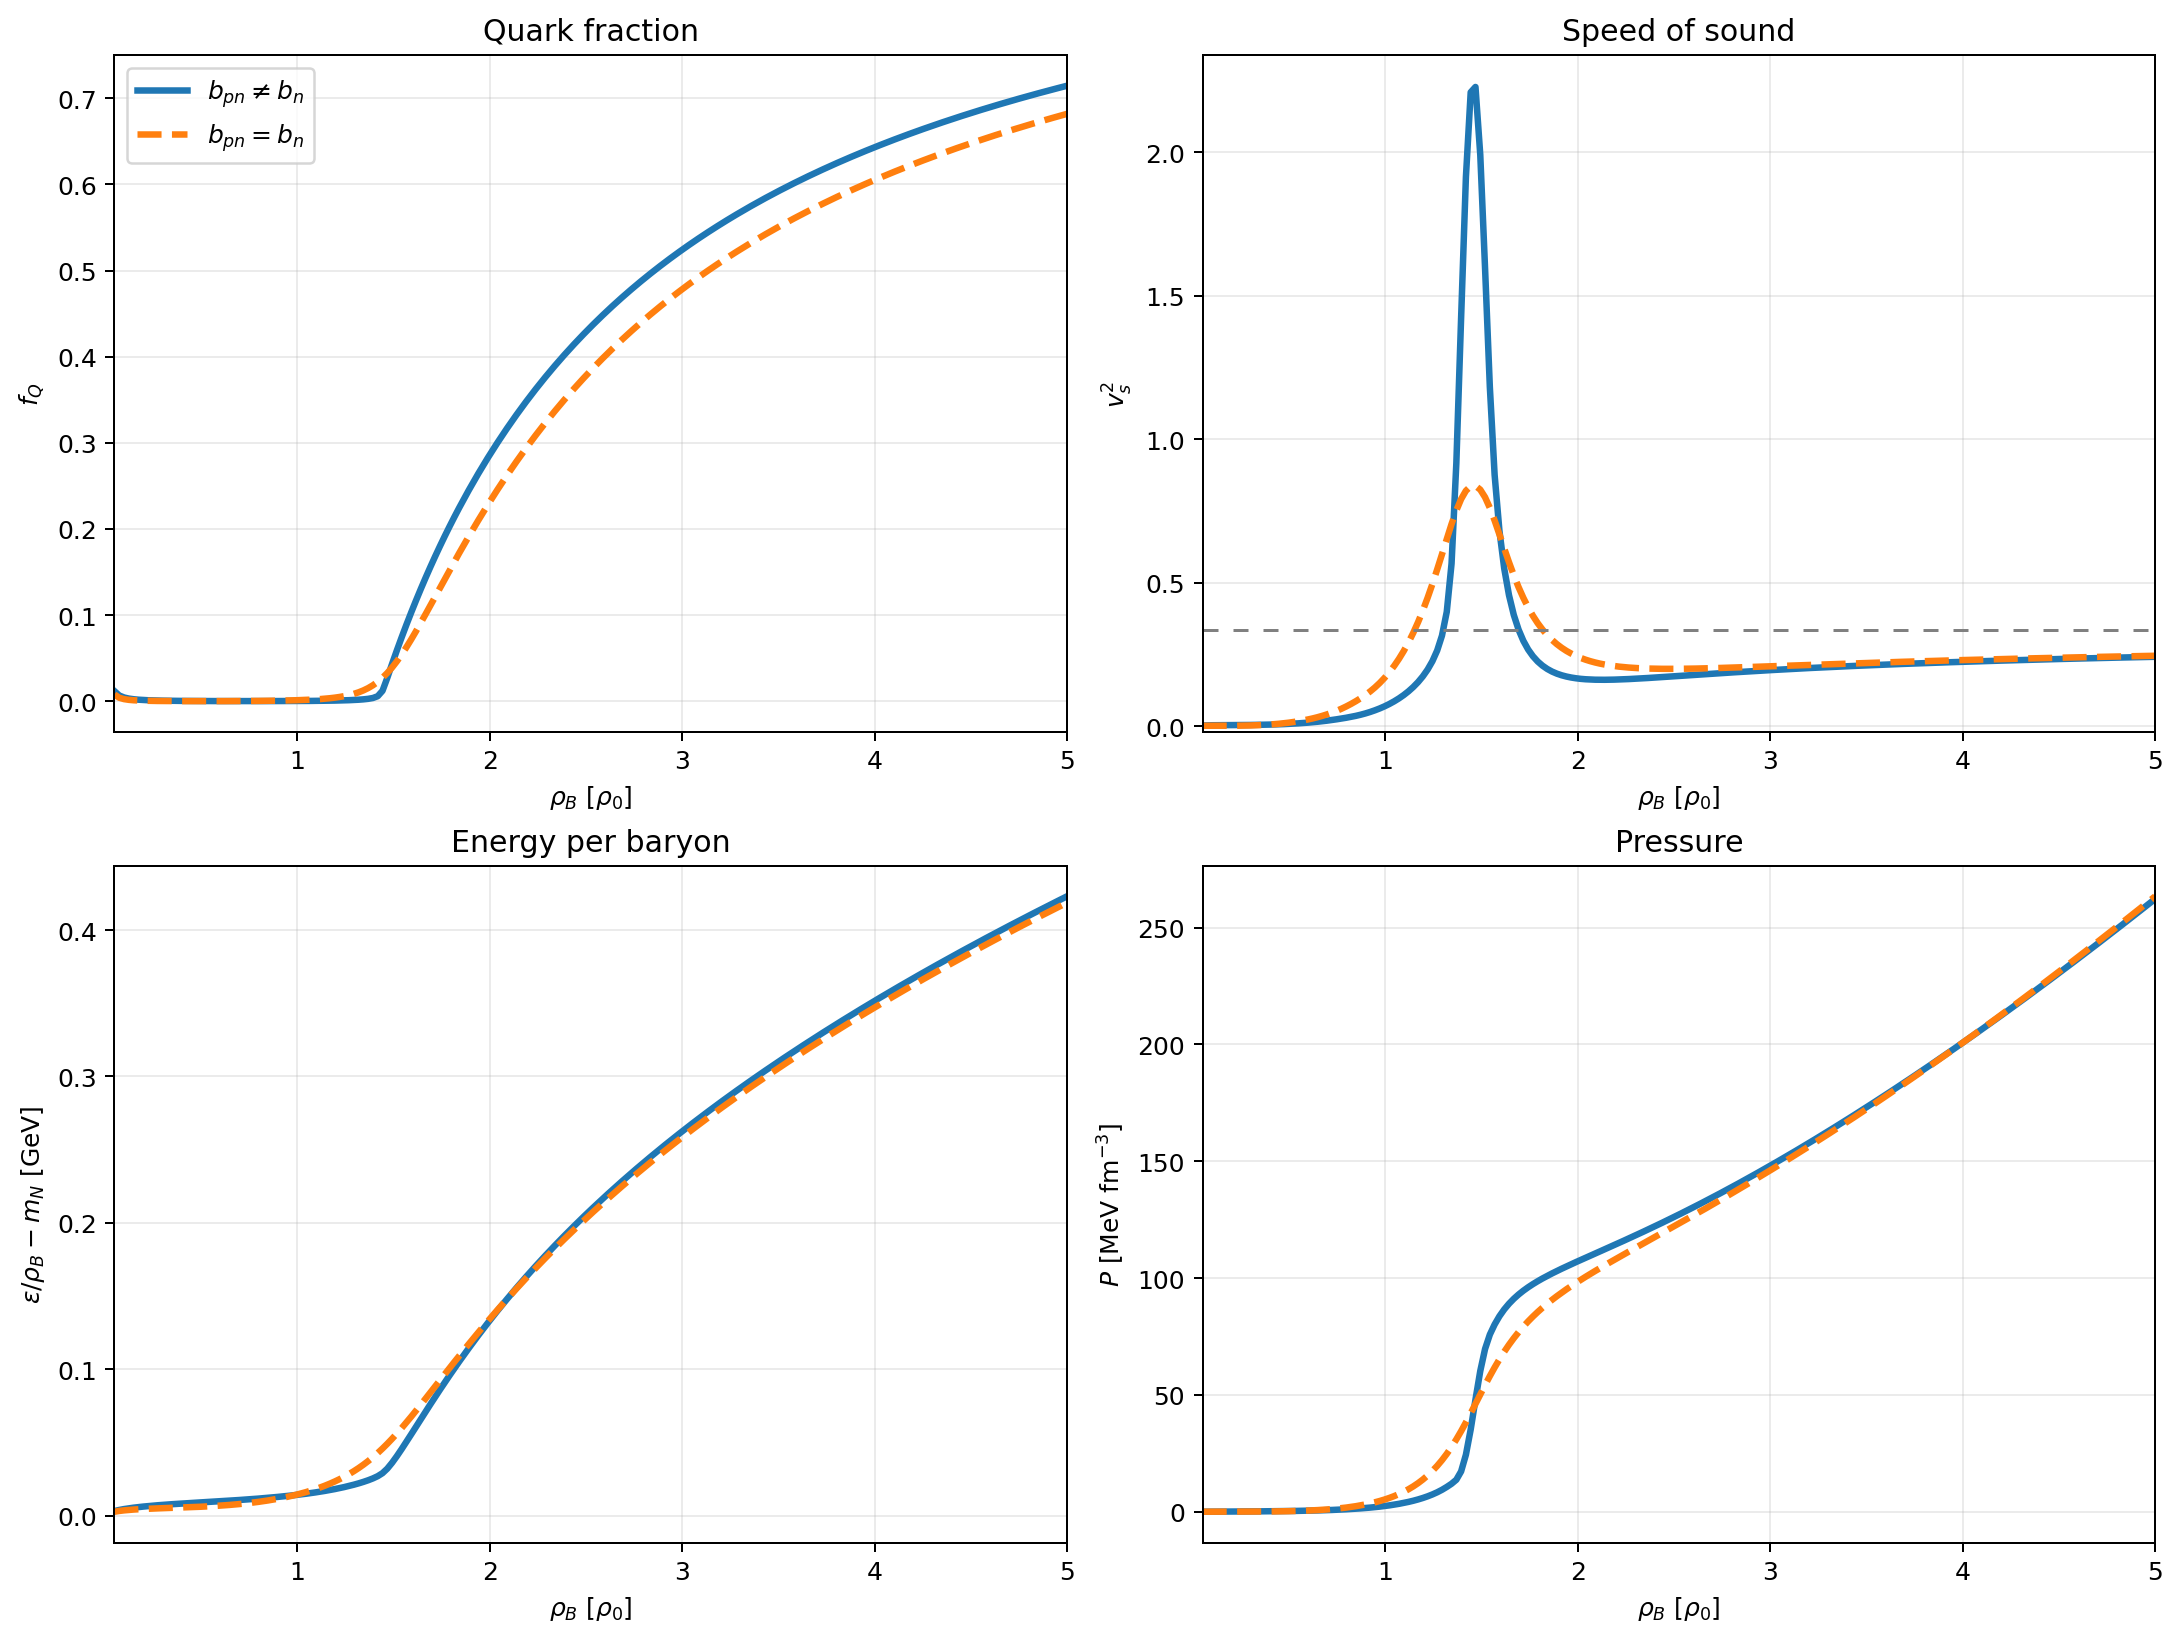

## vdw_test_2_target_l

**vdw_test_2_target_l_asymmetric_quarkyonic_png**  
`results/generated/vdw_test_2_target_l/vdw_test_2_target_l_asymmetric_quarkyonic.png`

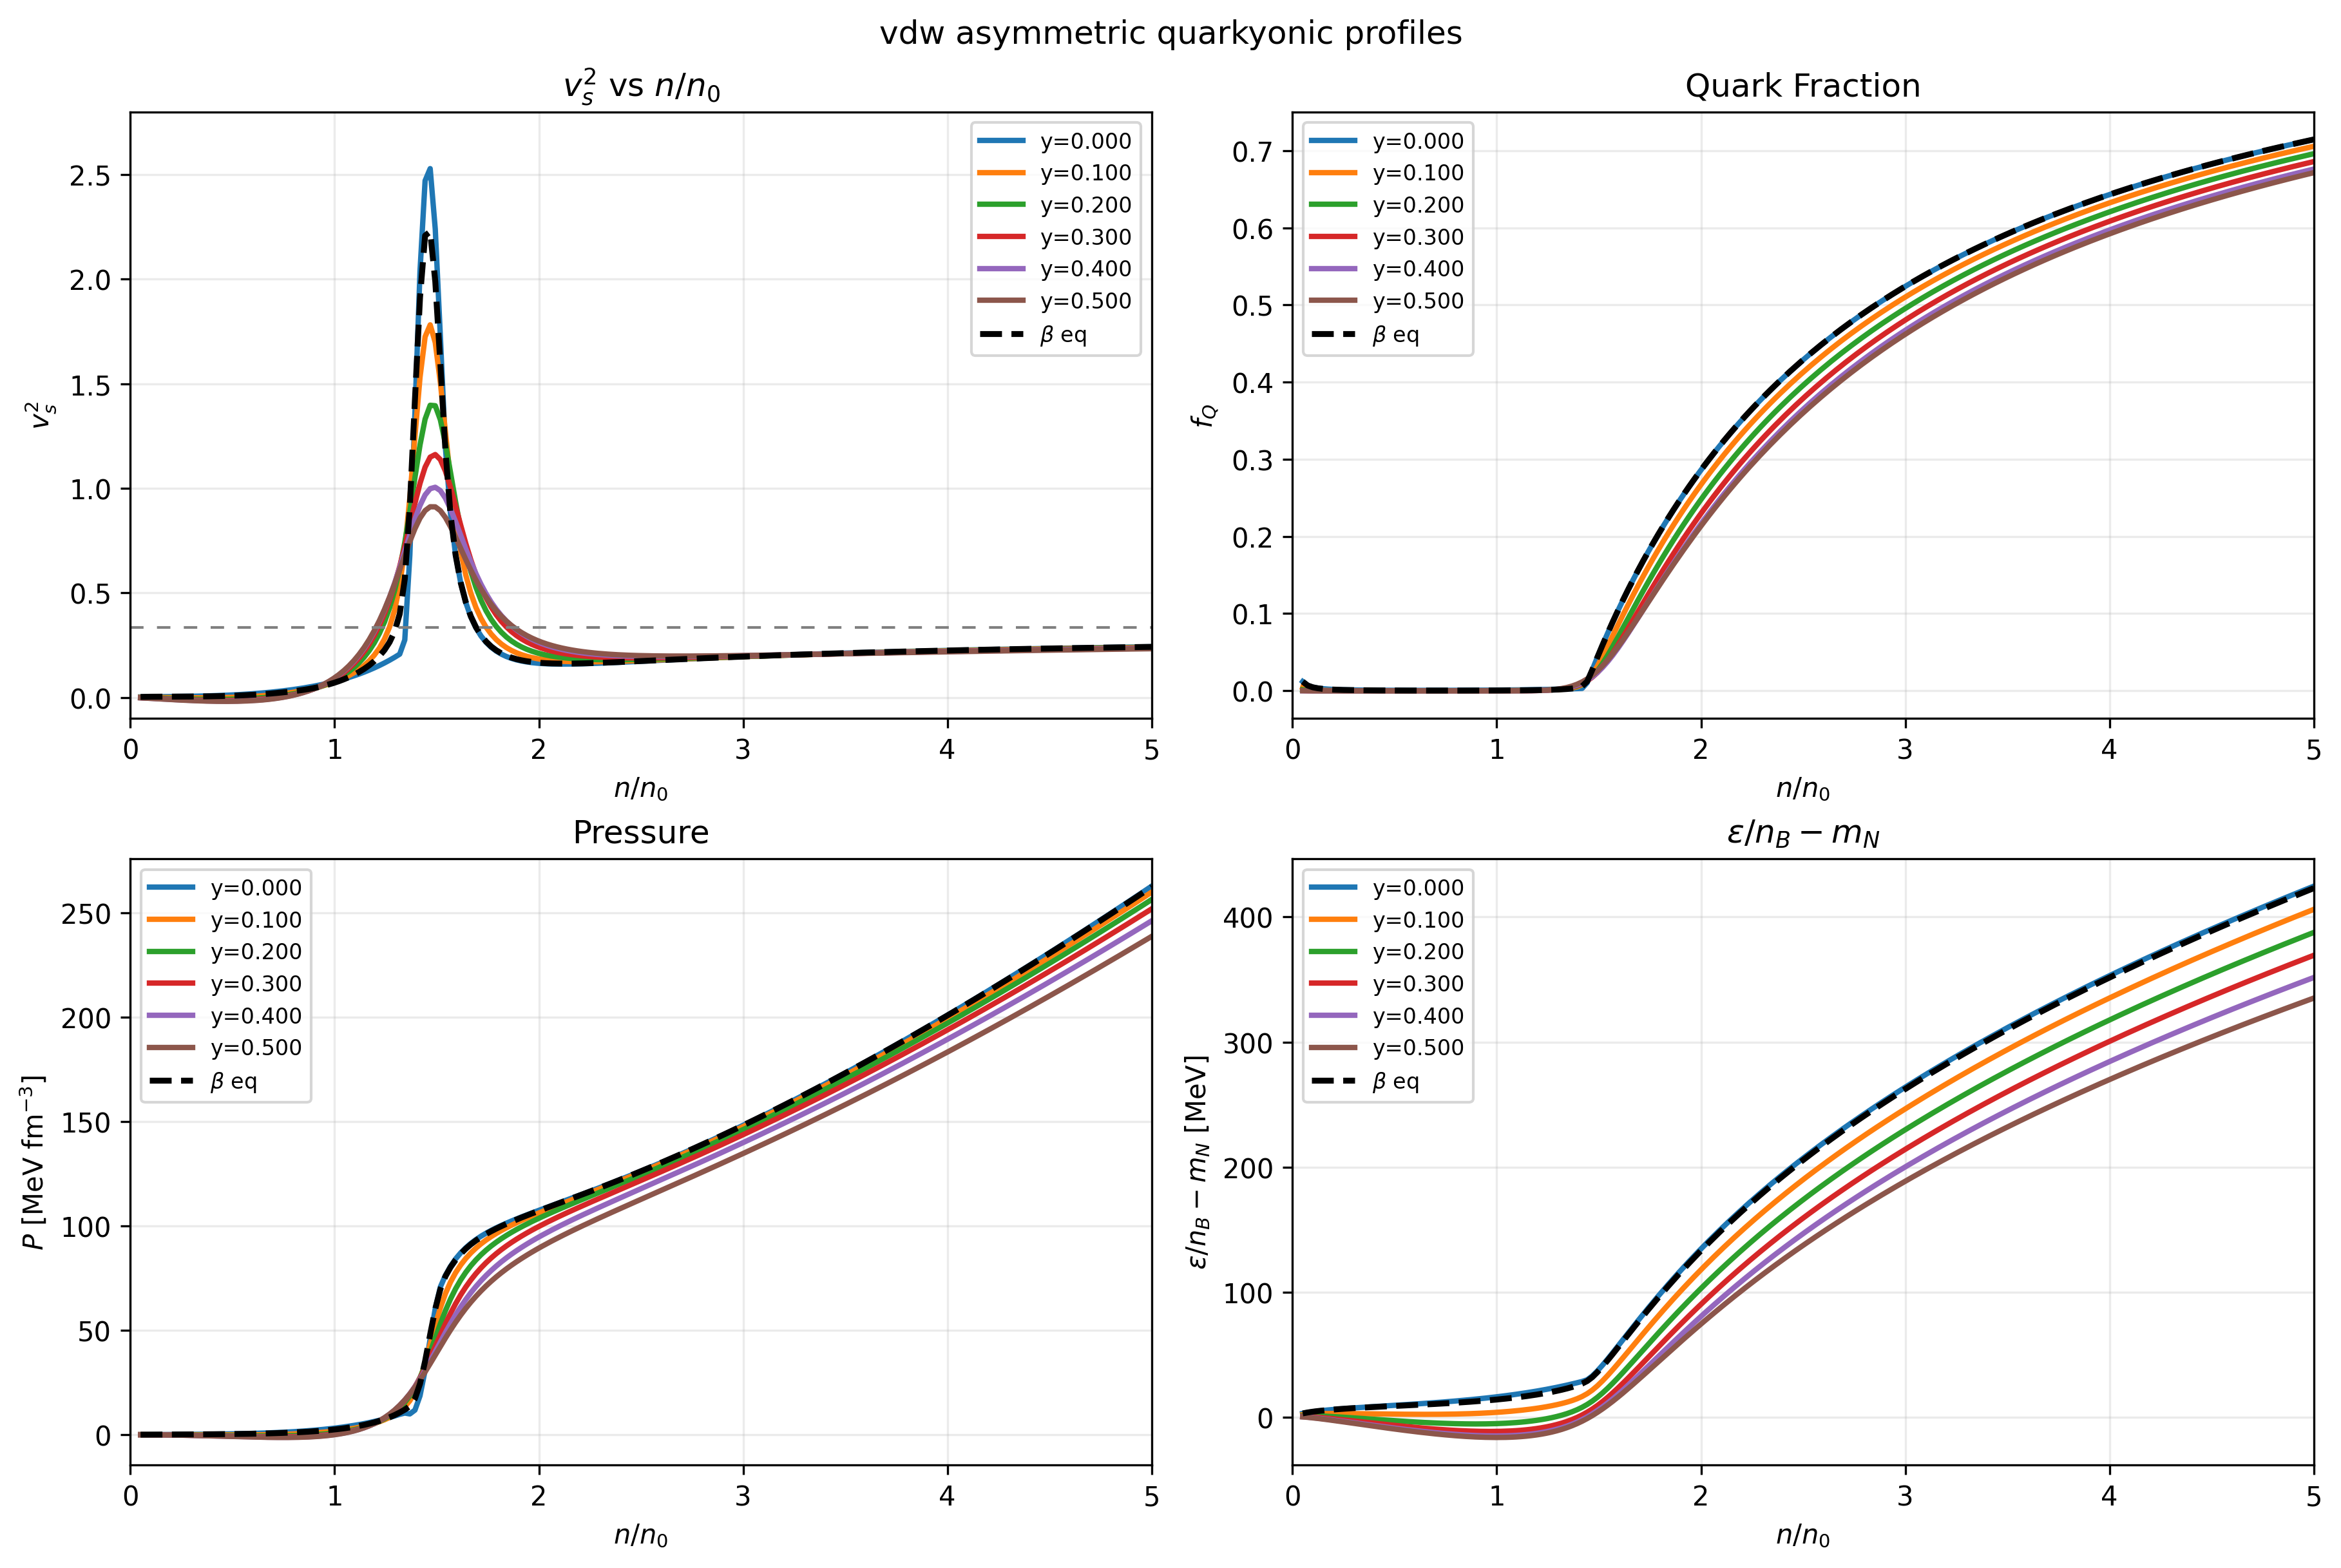

**vdw_test_2_target_l_beta_equilibrium_observables_png**  
`results/generated/vdw_test_2_target_l/vdw_test_2_target_l_beta_equilibrium_observables.png`

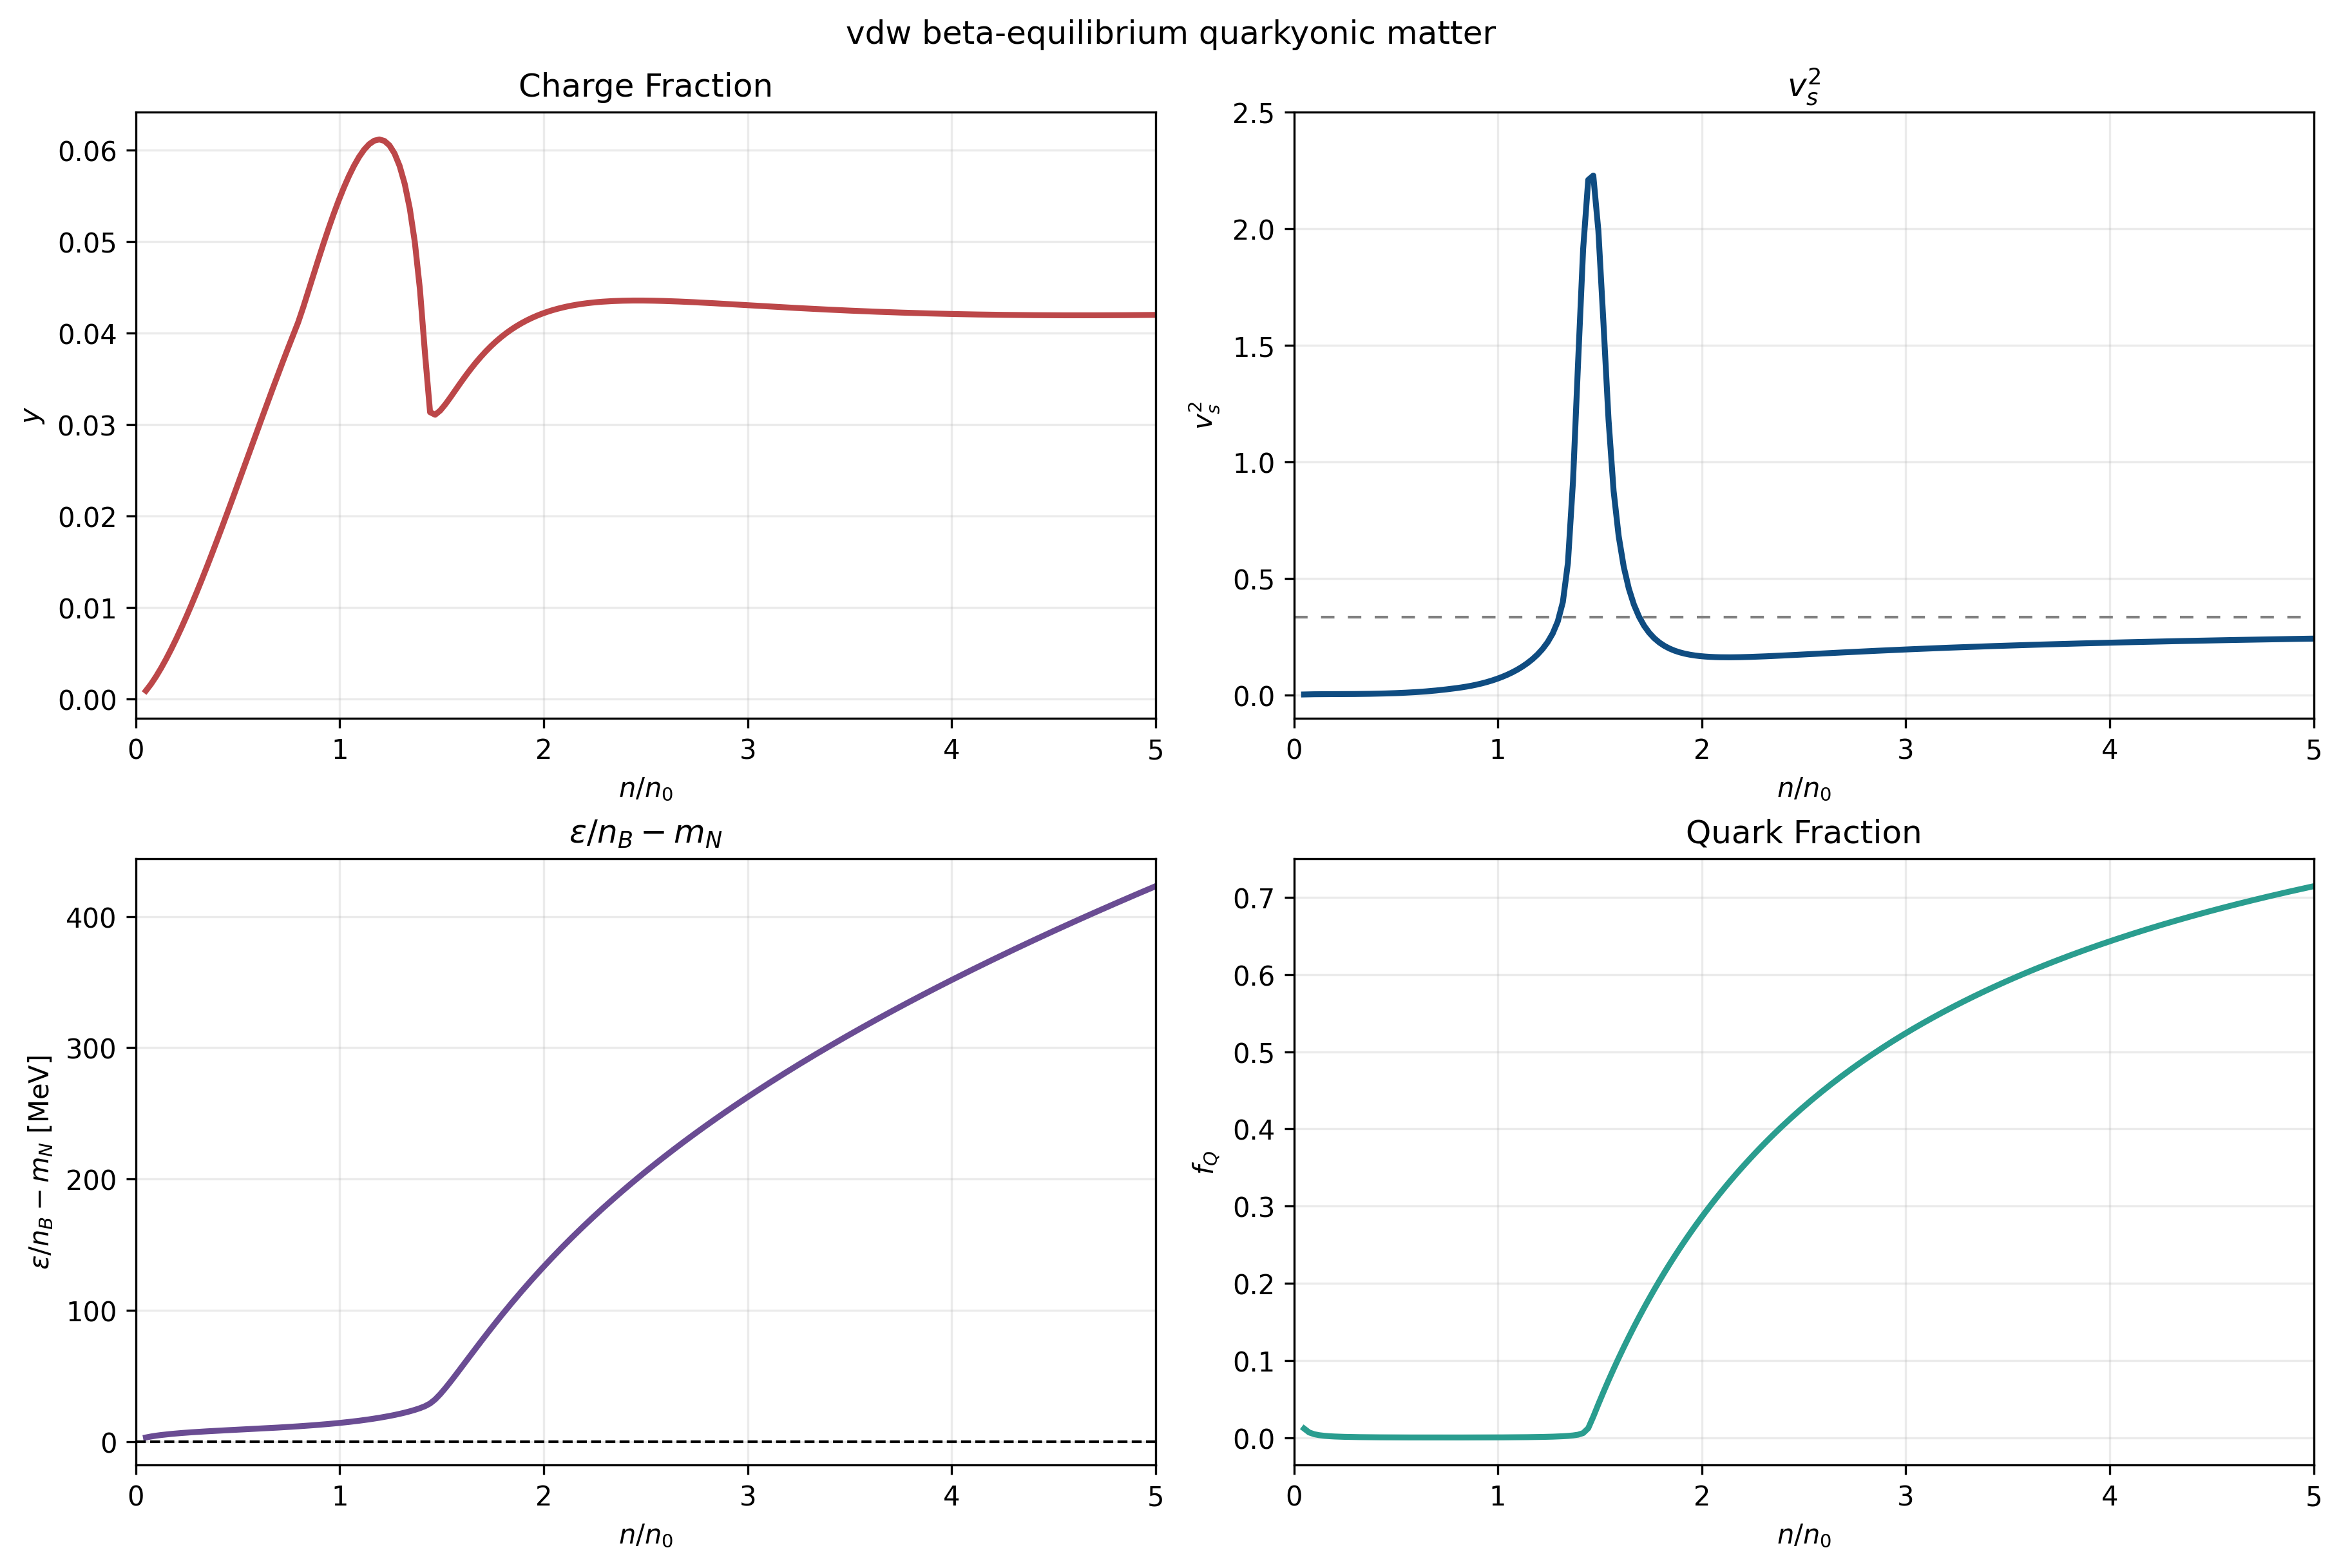

## vdw_test_2_equal_b

**vdw_test_2_equal_b_asymmetric_quarkyonic_png**  
`results/generated/vdw_test_2_equal_b/vdw_test_2_equal_b_asymmetric_quarkyonic.png`

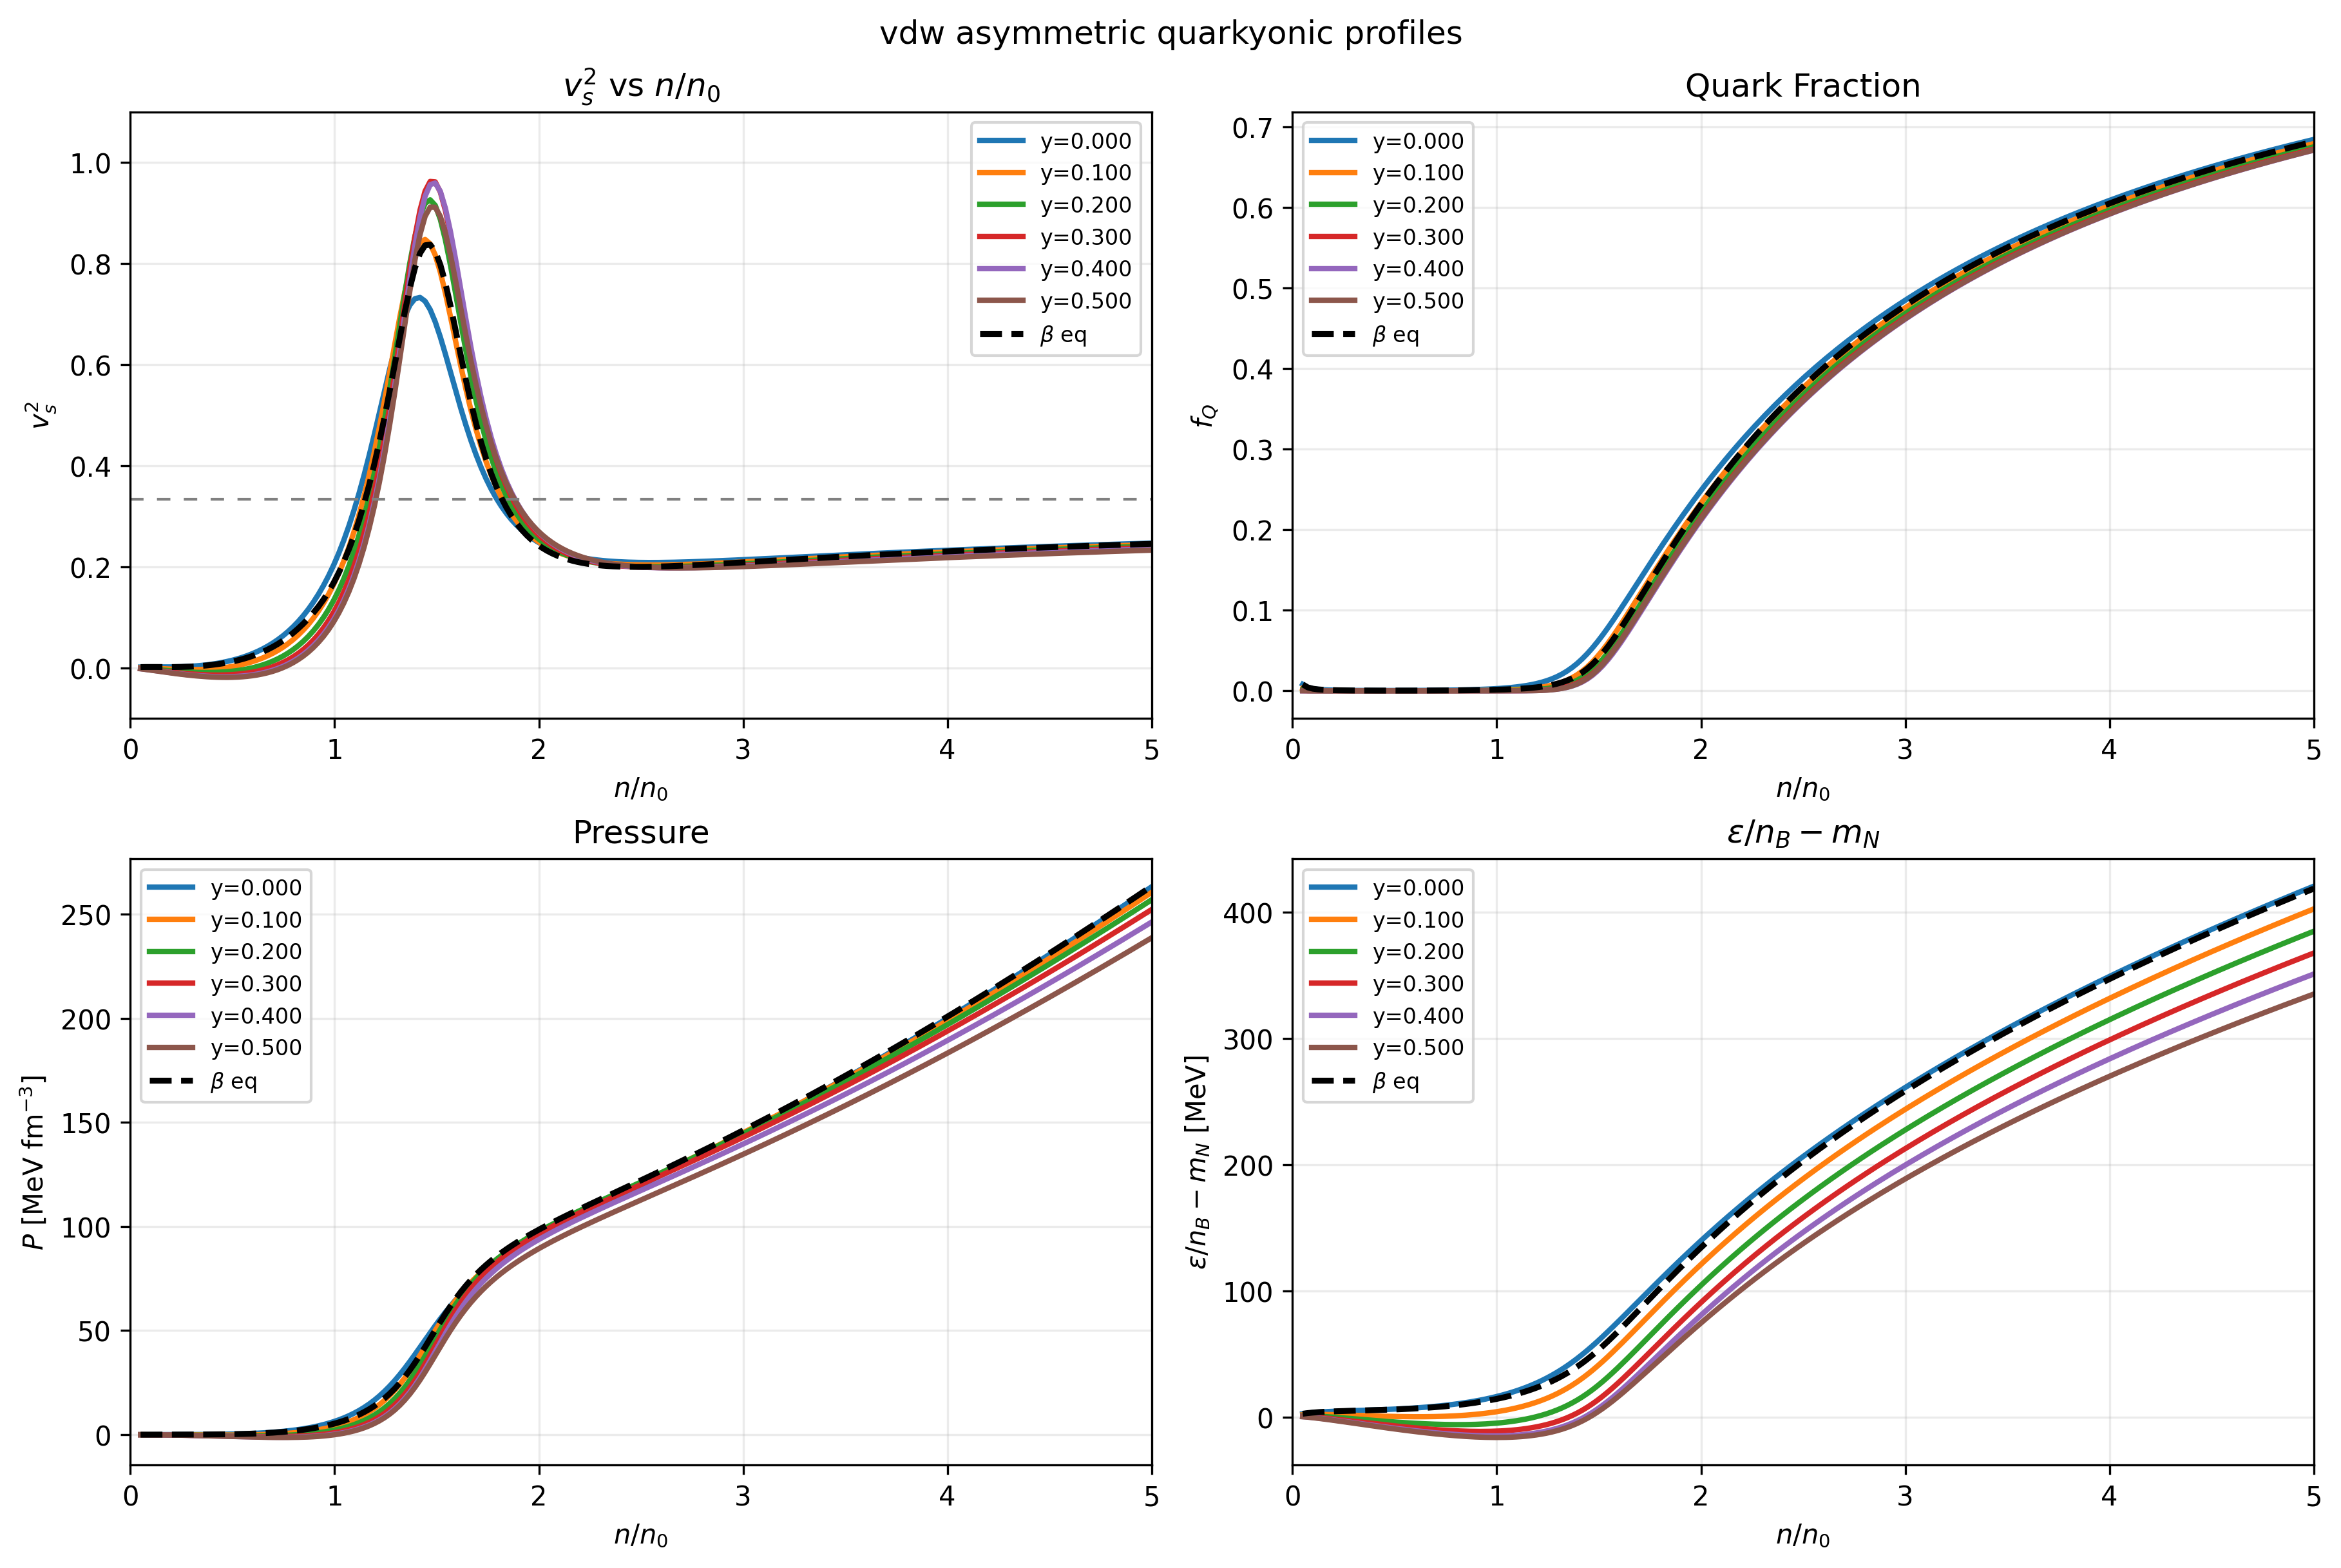

**vdw_test_2_equal_b_beta_equilibrium_observables_png**  
`results/generated/vdw_test_2_equal_b/vdw_test_2_equal_b_beta_equilibrium_observables.png`

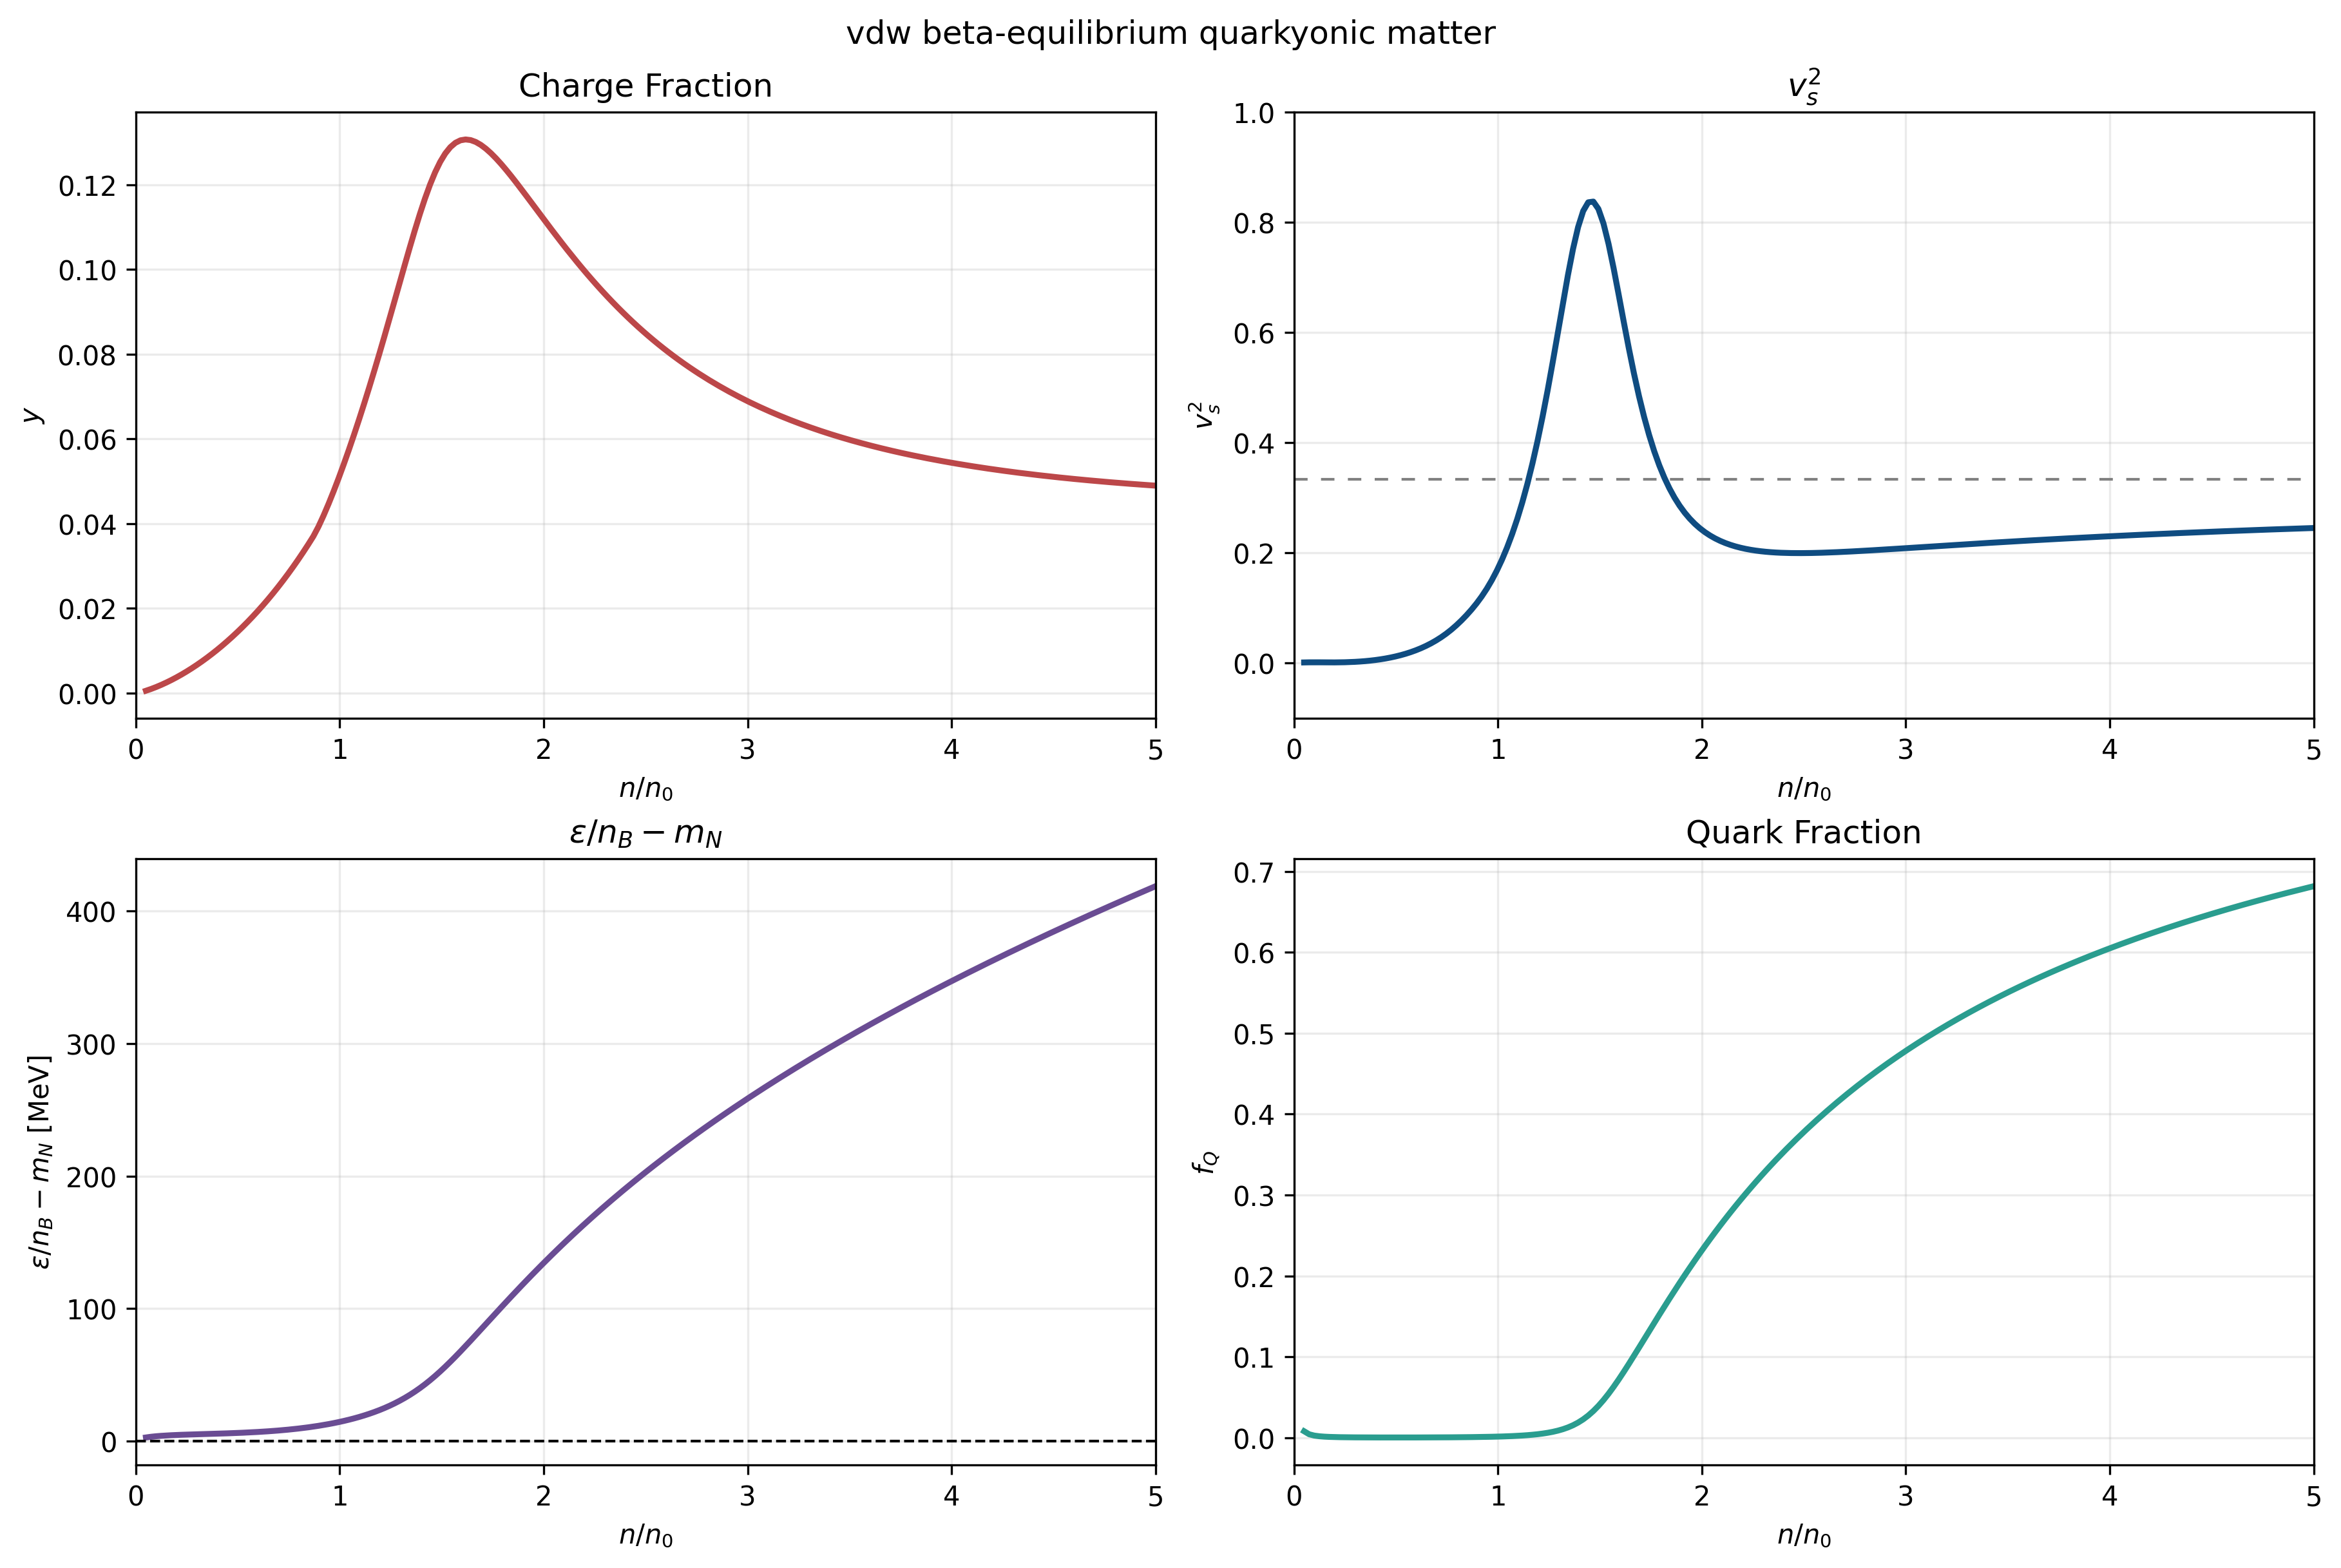

In [19]:
display_generated_plots(run_results)
